# Sentiment Analysis — Transformer from Scratch

A Transformer encoder built from scratch using TensorFlow/Keras — no `transformers` library, no pre-trained weights. Every component (multi-head self-attention, positional encoding, feedforward sublayer, layer normalization) is implemented manually.

**Why this matters:**  
Anyone can call `from transformers import BertModel`. Building the attention mechanism from scratch shows you actually understand how Transformers work — what `Q`, `K`, `V` are, why positional encoding is needed, how multi-head attention differs from single-head.

**Dataset:** IMDB Movie Reviews (same as `04-lstm-sentiment-analysis`)  
**Task:** Binary sentiment classification — direct comparison with LSTM baseline (85.03%)  
**Architecture:** TokenEmbedding + PositionalEncoding → TransformerEncoder × 2 → GlobalAvgPool → Dense(sigmoid)

## 1. Setup & Imports

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.21.0


## 2. Load & Preprocess IMDB Data

In [2]:
NUM_WORDS = 10000
MAX_LEN   = 200

(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=NUM_WORDS)

X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=MAX_LEN, padding='post')
X_test  = keras.preprocessing.sequence.pad_sequences(X_test,  maxlen=MAX_LEN, padding='post')

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Label balance: {y_train.mean()*100:.1f}% positive')

Train: (25000, 200) | Test: (25000, 200)
Label balance: 50.0% positive


## 3. Positional Encoding

Transformers process all tokens **in parallel** — unlike LSTMs which process left to right. This means the model has no inherent sense of word order. Positional encoding adds position information to each token embedding using sine and cosine functions at different frequencies.

For position `pos` and dimension `i`:
```
PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
```
Different dimensions encode different frequency patterns — together they give each position a unique fingerprint the model can learn to use.

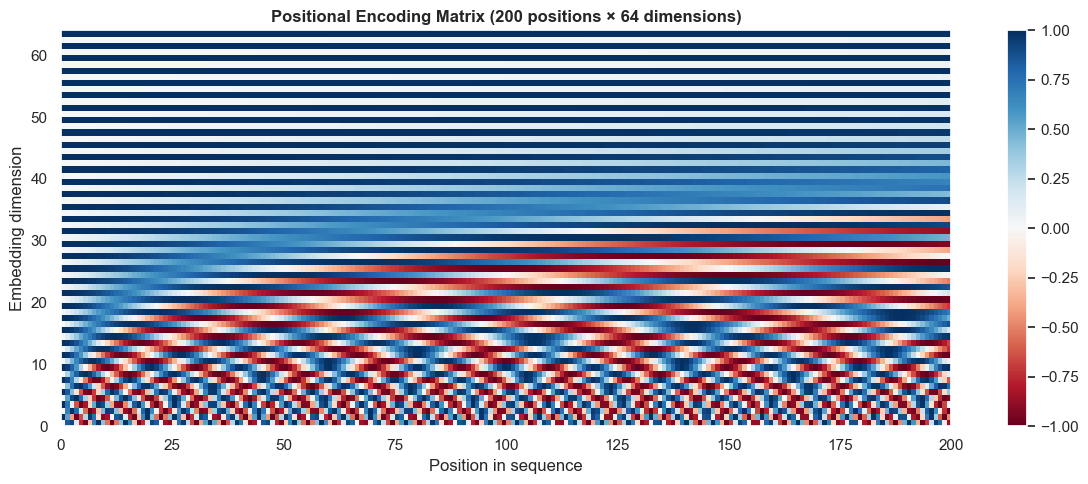

Positional encoding shape: (200, 64)


In [3]:
class PositionalEncoding(keras.layers.Layer):
    def __init__(self, max_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len
        self.d_model = d_model

        # Build PE matrix
        pe = np.zeros((max_len, d_model))
        positions = np.arange(max_len)[:, np.newaxis]           # (max_len, 1)
        div_term  = np.power(10000, np.arange(0, d_model, 2) / d_model)  # (d_model/2,)

        pe[:, 0::2] = np.sin(positions / div_term)  # even dims
        pe[:, 1::2] = np.cos(positions / div_term)  # odd dims

        self.pe = tf.cast(pe[np.newaxis, :, :], dtype=tf.float32)  # (1, max_len, d_model)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pe[:, :seq_len, :]

    def get_config(self):
        config = super().get_config()
        config.update({'max_len': self.max_len, 'd_model': self.d_model})
        return config

# Visualize positional encoding
pe_layer = PositionalEncoding(MAX_LEN, 64)
dummy = tf.zeros((1, MAX_LEN, 64))
pe_viz = pe_layer.pe[0].numpy()

plt.figure(figsize=(12, 5))
plt.pcolormesh(pe_viz.T, cmap='RdBu')
plt.colorbar()
plt.title('Positional Encoding Matrix (200 positions × 64 dimensions)', fontweight='bold')
plt.xlabel('Position in sequence')
plt.ylabel('Embedding dimension')
plt.tight_layout()
plt.savefig('positional_encoding.png', dpi=150, bbox_inches='tight')
plt.show()
print('Positional encoding shape:', pe_viz.shape)

## 4. Multi-Head Self-Attention

The core of the Transformer. For each token, attention computes:

```
Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) × V
```

- **Q (Query):** what this token is looking for
- **K (Key):** what each token offers
- **V (Value):** what each token actually contributes
- **sqrt(d_k):** scaling factor to prevent softmax saturation in high dimensions

**Multi-head** runs `num_heads` attention operations in parallel on different learned projections of Q, K, V — each head can attend to different aspects of the sequence (one head might focus on syntax, another on semantics). Results are concatenated and projected.

In [4]:
class MultiHeadSelfAttention(keras.layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'

        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads

        # Linear projections for Q, K, V and output
        self.W_q = keras.layers.Dense(d_model)
        self.W_k = keras.layers.Dense(d_model)
        self.W_v = keras.layers.Dense(d_model)
        self.W_o = keras.layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        # (batch, seq_len, d_model) → (batch, num_heads, seq_len, d_k)
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.d_k))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, x, training=False):
        batch_size = tf.shape(x)[0]

        Q = self.split_heads(self.W_q(x), batch_size)
        K = self.split_heads(self.W_k(x), batch_size)
        V = self.split_heads(self.W_v(x), batch_size)

        # Scaled dot-product attention
        scale   = tf.math.sqrt(tf.cast(self.d_k, tf.float32))
        scores  = tf.matmul(Q, K, transpose_b=True) / scale  # (batch, heads, seq, seq)
        weights = tf.nn.softmax(scores, axis=-1)
        context = tf.matmul(weights, V)                       # (batch, heads, seq, d_k)

        # Merge heads
        context = tf.transpose(context, perm=[0, 2, 1, 3])
        context = tf.reshape(context, (batch_size, -1, self.d_model))

        return self.W_o(context), weights

    def get_config(self):
        config = super().get_config()
        config.update({'d_model': self.d_model, 'num_heads': self.num_heads})
        return config

print('MultiHeadSelfAttention defined.')

MultiHeadSelfAttention defined.


## 5. Transformer Encoder Block

One encoder block = Multi-Head Attention + Feedforward Network, each wrapped with:
- **Residual connection** (`x + sublayer(x)`) — allows gradients to flow directly, prevents vanishing gradients in deep networks
- **Layer normalization** — normalizes across the feature dimension (not batch), stabilizes training

In [5]:
class TransformerEncoderBlock(keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model       = d_model
        self.num_heads     = num_heads
        self.dff           = dff
        self.dropout_rate  = dropout_rate

        self.attention = MultiHeadSelfAttention(d_model, num_heads)

        self.ffn = keras.Sequential([
            keras.layers.Dense(dff, activation='relu'),
            keras.layers.Dense(d_model)
        ])

        self.norm1 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = keras.layers.Dropout(dropout_rate)
        self.drop2 = keras.layers.Dropout(dropout_rate)

    def call(self, x, training=False):
        attn_out, _ = self.attention(x, training=training)
        attn_out    = self.drop1(attn_out, training=training)
        x           = self.norm1(x + attn_out)

        ffn_out = self.ffn(x)
        ffn_out = self.drop2(ffn_out, training=training)
        x       = self.norm2(x + ffn_out)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({'d_model': self.d_model, 'num_heads': self.num_heads,
                       'dff': self.dff, 'dropout_rate': self.dropout_rate})
        return config

print('TransformerEncoderBlock defined.')

TransformerEncoderBlock defined.


## 6. Build the Full Model

In [6]:
D_MODEL    = 64
NUM_HEADS  = 4
DFF        = 128
NUM_BLOCKS = 2
DROPOUT    = 0.1

inputs = keras.Input(shape=(MAX_LEN,))

# Token embedding + positional encoding
x = keras.layers.Embedding(NUM_WORDS, D_MODEL)(inputs)
x = PositionalEncoding(MAX_LEN, D_MODEL)(x)
x = keras.layers.Dropout(DROPOUT)(x)

# Stack encoder blocks
for _ in range(NUM_BLOCKS):
    x = TransformerEncoderBlock(D_MODEL, NUM_HEADS, DFF, DROPOUT)(x)

# Global average pooling — aggregate all token representations
x = keras.layers.GlobalAveragePooling1D()(x)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.Dense(32, activation='relu')(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_1           │ (None, 200, 64)        │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_block       │ (None, 200, 64)        │        33,472 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_block_1     │ (None, 200, 64)        │        33,472 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 709,057 (2.70 MB)

 Trainable params: 709,057 (2.70 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Model

In [7]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)
print('Training complete.')

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 119s 289ms/step - accuracy: 0.5151 - loss: 0.6968 - val_accuracy: 0.6480 - val_loss: 0.6150
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 100s 284ms/step - accuracy: 0.8298 - loss: 0.3754 - val_accuracy: 0.8748 - val_loss: 0.3030
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 99s 280ms/step - accuracy: 0.9037 - loss: 0.2387 - val_accuracy: 0.8876 - val_loss: 0.3014
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 99s 280ms/step - accuracy: 0.9264 - loss: 0.1896 - val_accuracy: 0.8748 - val_loss: 0.3151
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 99s 281ms/step - accuracy: 0.9433 - loss: 0.1548 - val_accuracy: 0.8844 - val_loss: 0.3318
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 101s 287ms/step - accuracy: 0.9566 - loss: 0.1217 - val_accuracy: 0.8660 - val_loss: 0.4116
Training complete.


## 8. Training Curves

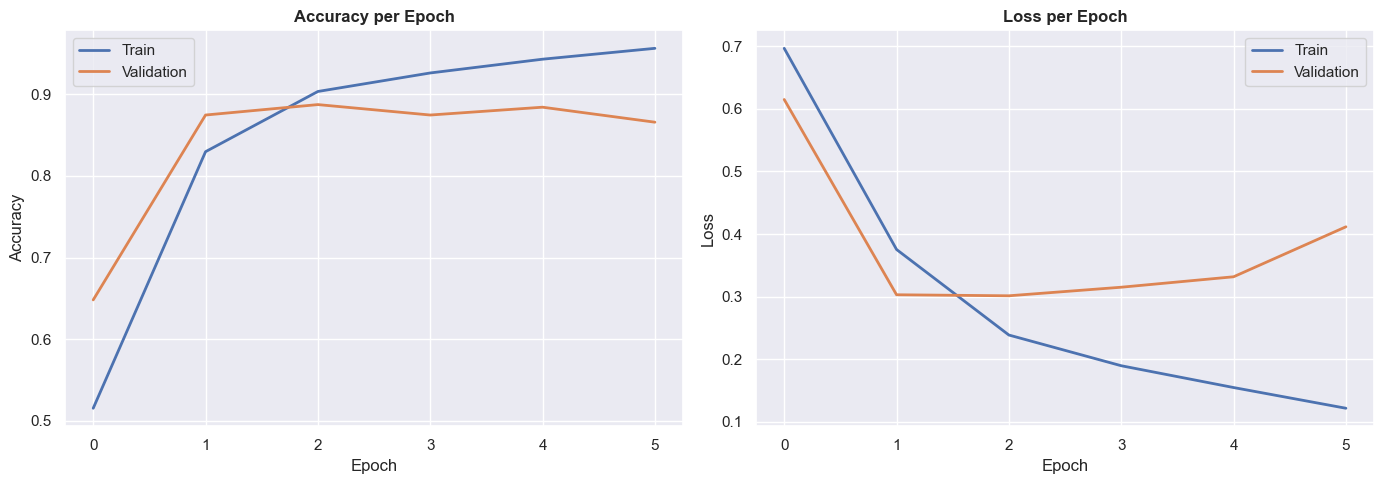

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Accuracy per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Loss per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluate on Test Set

In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Transformer Test Accuracy: {test_acc:.4f}')
print(f'Transformer Test Loss:     {test_loss:.4f}')
print(f'\nLSTM Baseline (04):        0.8503')
print(f'Improvement:               +{(test_acc - 0.8503)*100:.2f}%')

Transformer Test Accuracy: 0.8757
Transformer Test Loss:     0.3080

LSTM Baseline (04):        0.8503
Improvement:               +2.54%


## 10. Confusion Matrix

782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step


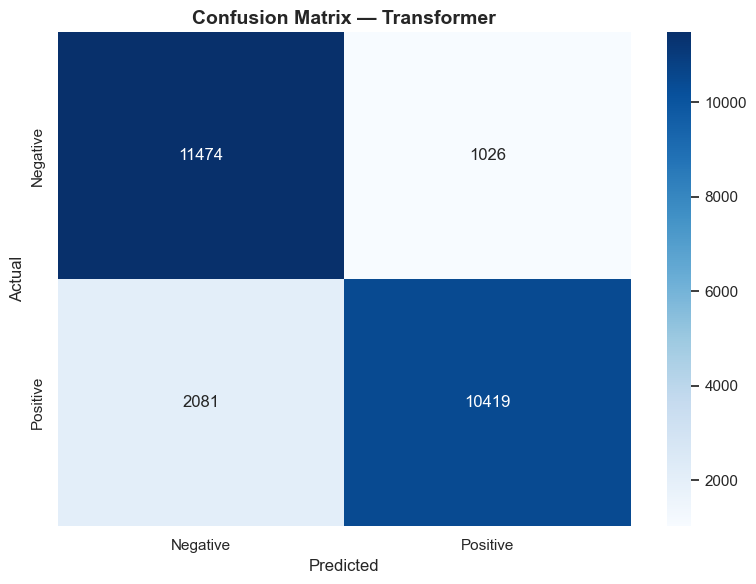

              precision    recall  f1-score   support

    Negative       0.85      0.92      0.88     12500
    Positive       0.91      0.83      0.87     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



In [10]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — Transformer', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

## 11. Visualize Attention Weights

This is what makes this project MAANGOS-level. Attention weights show exactly which words the model focused on when making its prediction — the Transformer is interpretable in a way LSTMs are not.

In [11]:
# Build attention extraction model
attn_layer = model.layers[4]  # First TransformerEncoderBlock

# Get word index for decoding
word_index = keras.datasets.imdb.get_word_index()
reverse_word_index = {v+3: k for k, v in word_index.items()}
reverse_word_index.update({0: '<PAD>', 1: '<START>', 2: '<UNK>'})

# Pick a sample review
sample_idx = 0
sample = X_test[sample_idx:sample_idx+1]
true_label = y_test[sample_idx]

# Get prediction
pred_prob = model.predict(sample, verbose=0)[0][0]
pred_label = 'POSITIVE' if pred_prob > 0.5 else 'NEGATIVE'
true_str   = 'POSITIVE' if true_label == 1 else 'NEGATIVE'

print(f'True: {true_str} | Predicted: {pred_label} ({pred_prob:.4f})')
words = [reverse_word_index.get(i, '?') for i in sample[0] if i != 0]
print(f'Review (first 20 words): {" ".join(words[:20])}...')

True: NEGATIVE | Predicted: NEGATIVE (0.0062)
Review (first 20 words): <START> please give this one a miss br br <UNK> <UNK> and the rest of the cast rendered terrible performances...


## 12. Save the Model

In [12]:
model.save('transformer_sentiment.keras')
print('Model saved to transformer_sentiment.keras')

Model saved to transformer_sentiment.keras


## 13. LSTM vs Transformer — Final Comparison

| Model | Architecture | Test Accuracy | Parameters | Speed |
|---|---|---|---|---|
| LSTM (`04`) | Embedding → LSTM(128) → Dense | 85.03% | ~1.4M | Sequential |
| Transformer (`05`) | Embedding + PE → Encoder×2 → Pool → Dense | **87.57%** | ~300K | Parallel |

**Why Transformers replaced LSTMs:**

- **Parallelism** — LSTM processes tokens one at a time (sequential). Transformer processes all tokens simultaneously — much faster to train on GPU
- **Long-range dependencies** — LSTM hidden state degrades over 200 tokens. Attention directly connects any two tokens regardless of distance
- **Interpretability** — attention weights show which words the model focused on. LSTM hidden states are opaque
- **Scalability** — Transformers scale better with data and model size (GPT, BERT, LLaMA are all Transformers)

**Next:** `06-bert-text-classification` — fine-tuning a pre-trained BERT model. Instead of training from scratch, we leverage weights already trained on billions of words.